In [1]:
climate <- matrix(c(
  9.2, 1.1, 0.8,
  6.5, 0.9, 1.2,
  2.3, 0.7, 2.5,
  3.8, 1.0, 1.5,
  7.1, 1.2, 0.9
), nrow=5, byrow=TRUE)

colnames(climate) <- c("CO2", "Temp", "Deforestation")
rownames(climate) <- c("A", "B", "C", "D", "E")

scaled_climate <- scale(climate)

In [2]:
cor_matrix <- cor(scaled_climate)
print(cor_matrix)

                     CO2       Temp Deforestation
CO2            1.0000000  0.7490355    -0.9195016
Temp           0.7490355  1.0000000    -0.8976824
Deforestation -0.9195016 -0.8976824     1.0000000


In [4]:
library(reshape2)

melted <- melt(cor_matrix)
head(melted)

,Var1,Var2,value
,<fct>,<fct>,<dbl>
1,CO2,CO2,1.0000000
2,Temp,CO2,0.7490355
3,Deforestation,CO2,-0.9195016
4,CO2,Temp,0.7490355
5,Temp,Temp,1.0000000
6,Deforestation,Temp,-0.8976824


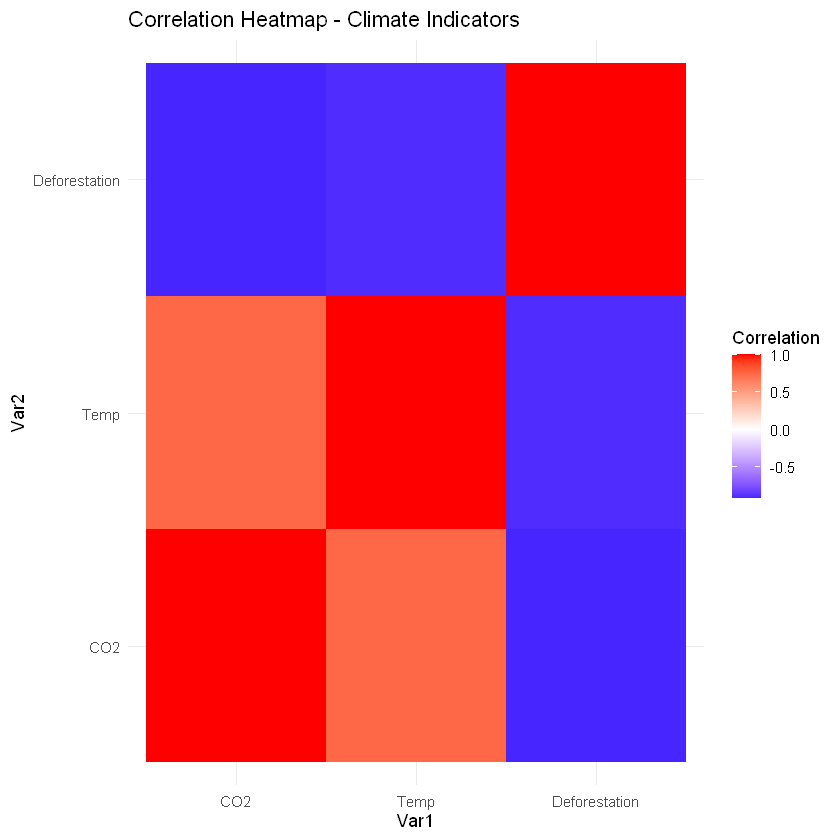

In [5]:
library(ggplot2)

ggplot(melted, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile() +
  scale_fill_gradient2(low = "blue", high = "red", mid = "white", midpoint = 0) +
  theme_minimal() +
  labs(title = "Correlation Heatmap - Climate Indicators",
       fill = "Correlation")

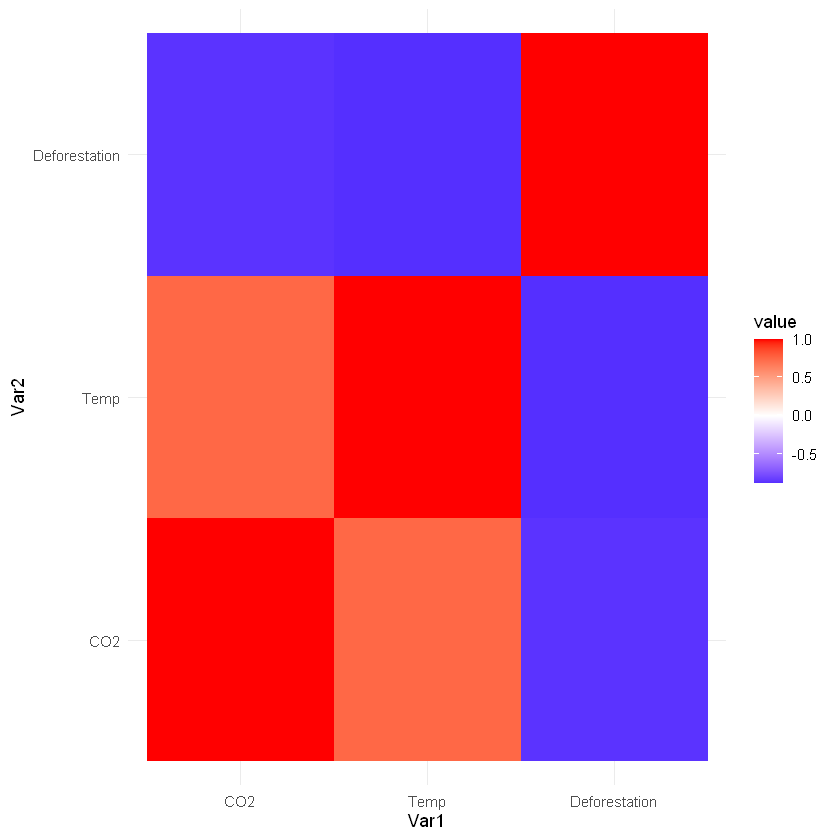

In [6]:
# Modify row 3 (Country C)
climate[3, ] <- c(2.3, 0.7, 3.2)  # higher deforestation

# Re-scale and re-plot
scaled_climate <- scale(climate)
cor_matrix <- cor(scaled_climate)
melted <- melt(cor_matrix)

ggplot(melted, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile() +
  scale_fill_gradient2(low = "blue", high = "red", mid = "white", midpoint = 0) +
  theme_minimal()